# 3º Entregável — Modelagem de Machine Learning

**Empresa parceira:** Sompo Seguros  
**Integrantes:** Gustavo Hideki Ychii — RM 571745 | Enzo Gabriel Lima Miranda — RM 573094

## Objetivo

Neste notebook, nosso objetivo é criar modelos capazes de prever o **nível de risco de uma apólice**. A variável escolhida como alvo foi `Nivel_Risco`, que possui quatro categorias: Baixo, Médio, Alto e Muito Alto.

Foram comparados dois modelos de classificação: **Regressão Logística** e **Random Forest**. Também usamos holdout, métricas de avaliação, ajuste de hiperparâmetros e importância das variáveis.

## 1. Importação das bibliotecas e leitura da base

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)
url_base = "https://raw.githubusercontent.com/EnzoGabrielMiranda/sprint-3-ml/main/Base_Dados_Sompo_Seguros.xlsx"

df = pd.read_excel(url_base, sheet_name="Base de Dados")

print("Dimensão da base:", df.shape)
df.head()

Dimensão da base: (120, 13)


,ID_Apolice,Sexo_Segurado,Regiao,UF,Tipo_Seguro,Cobertura,Nivel_Risco,Satisfacao_Cliente,Idade_Segurado,Qtd_Sinistros,Anos_Cliente,Premio_Anual_R$,Valor_Indenizado_R$
0,1,Masculino,Sul,RS,Empresarial,Básica,Médio,Satisfeito,32,0,13,4827.39,0.00
1,2,Masculino,Sudeste,RJ,Rural,Básica,Médio,Satisfeito,22,1,7,3230.16,2127.29
2,3,Masculino,Sudeste,ES,Empresarial,Ampla,Médio,Insatisfeito,30,0,8,10889.35,0.00
3,4,Feminino,Sudeste,RJ,Residencial,Ampla,Baixo,Satisfeito,46,2,19,1626.15,7170.96
4,5,Feminino,Sul,RS,Vida,Familiar,Médio,Insatisfeito,45,1,19,2070.73,2751.54


## 2. Verificação inicial

Antes de treinar os modelos, verificamos dados ausentes, duplicados e a distribuição da variável alvo. A base tem somente 120 registros, então os resultados devem ser interpretados como um experimento acadêmico.

In [3]:
print("Valores ausentes:", df.isna().sum().sum())
print("Linhas duplicadas:", df.duplicated().sum())
print("\nDistribuição do risco:")
print(df["Nivel_Risco"].value_counts())

Valores ausentes: 0
Linhas duplicadas: 0

Distribuição do risco:
Nivel_Risco
Médio         54
Baixo         31
Alto          23
Muito Alto    12
Name: count, dtype: int64


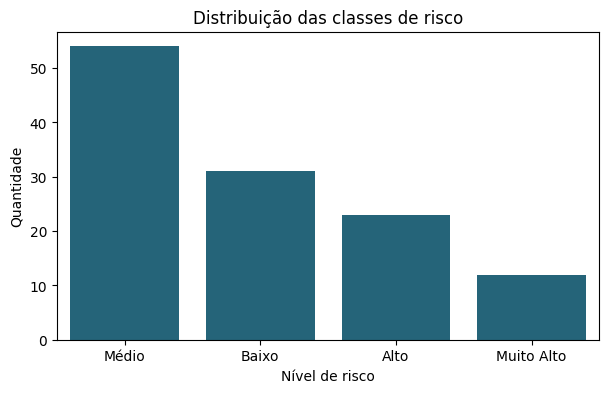

In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Nivel_Risco", order=df["Nivel_Risco"].value_counts().index, color="#176B87")
plt.title("Distribuição das classes de risco")
plt.xlabel("Nível de risco")
plt.ylabel("Quantidade")
plt.show()

A classe **Médio** é a mais comum e **Muito Alto** é a menos frequente. Para diminuir o efeito desse desequilíbrio, usamos divisão estratificada e `class_weight='balanced'` nos modelos iniciais.

## 3. Separação das variáveis e preparação dos dados

In [5]:
target = "Nivel_Risco"
X = df.drop(columns=["ID_Apolice", target])
y = df[target]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Variáveis categóricas:", cat_cols)
print("Variáveis numéricas:", num_cols)

Variáveis categóricas: ['Sexo_Segurado', 'Regiao', 'UF', 'Tipo_Seguro', 'Cobertura', 'Satisfacao_Cliente']
Variáveis numéricas: ['Idade_Segurado', 'Qtd_Sinistros', 'Anos_Cliente', 'Premio_Anual_R$', 'Valor_Indenizado_R$']


O campo `ID_Apolice` foi removido porque funciona apenas como identificador. Nas variáveis categóricas, aplicamos **One-Hot Encoding**. Nas numéricas, usamos **StandardScaler**, necessário principalmente para a Regressão Logística. Todo o tratamento foi colocado em um pipeline para evitar vazamento de dados.

In [6]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("\nClasses no teste:")
print(y_test.value_counts())

Treino: (84, 11)
Teste: (36, 11)

Classes no teste:
Nivel_Risco
Médio         16
Baixo          9
Alto           7
Muito Alto     4
Name: count, dtype: int64


## 4. Treinamento e validação holdout

Usamos 70% da base para treino e 30% para teste. O conjunto de teste ficou separado durante o treinamento. As métricas foram calculadas com média ponderada, pois as classes possuem tamanhos diferentes.

In [7]:
models = {
    "Regressão Logística": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
}

results = []
fitted = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, pred, average="weighted", zero_division=0),
        "AUC": roc_auc_score(y_test, proba, labels=pipe.classes_, multi_class="ovr", average="weighted")
    })
    fitted[name] = (pipe, pred)

results_df = pd.DataFrame(results).set_index("Modelo")
results_df.round(3)

,Accuracy,Precision,Recall,F1-score,AUC
Modelo,,,,,
Regressão Logística,0.278,0.278,0.278,0.278,0.481
Random Forest,0.333,0.246,0.333,0.274,0.438


A comparação mostra que o melhor resultado inicial pelo F1-score ponderado foi o modelo **Regressão Logística**, com F1 de **0.278**. Como a base é pequena e as classes se misturam bastante, o desempenho não é alto. Isso indica que as variáveis atuais ainda não explicam completamente o nível de risco.

## 5. Matriz de confusão e relatório de classificação

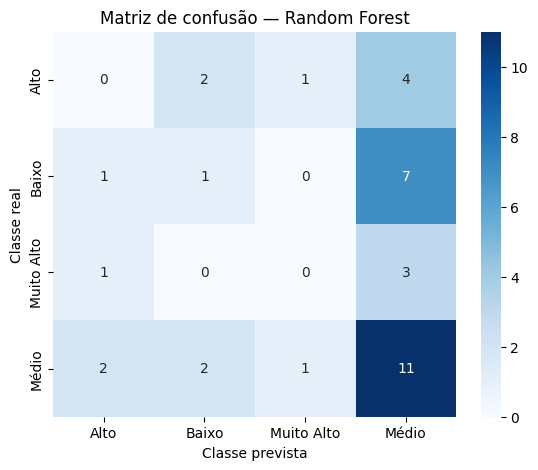

In [8]:
rf_pipe, rf_pred = fitted["Random Forest"]
labels = rf_pipe.classes_
cm = confusion_matrix(y_test, rf_pred, labels=labels)

plt.figure(figsize=(6.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Matriz de confusão — Random Forest")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.show()

In [9]:
print(classification_report(y_test, rf_pred, zero_division=0))

              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00         7
       Baixo       0.20      0.11      0.14         9
  Muito Alto       0.00      0.00      0.00         4
       Médio       0.44      0.69      0.54        16

    accuracy                           0.33        36
   macro avg       0.16      0.20      0.17        36
weighted avg       0.25      0.33      0.27        36



A matriz mostra em quais classes o modelo mais errou. Como havia poucos exemplos de risco Muito Alto, essa classe foi mais difícil de aprender. Esse é um ponto que deve ser melhorado com mais dados.

## 6. Tuning básico do Random Forest

In [ ]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__class_weight": [None, "balanced"]
}

tuned_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

grid = GridSearchCV(tuned_pipe, param_grid, scoring="f1_weighted", cv=4, n_jobs=-1)
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor F1 médio na validação cruzada:", round(grid.best_score_, 3))

In [ ]:
tuned = grid.best_estimator_
tuned_pred = tuned.predict(X_test)
tuned_proba = tuned.predict_proba(X_test)

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, tuned_pred, average="weighted", zero_division=0),
    "F1-score": f1_score(y_test, tuned_pred, average="weighted", zero_division=0),
    "AUC": roc_auc_score(y_test, tuned_proba, labels=tuned.classes_, multi_class="ovr", average="weighted")
}

pd.Series(tuned_metrics).round(3)

O tuning alterou o F1-score em **+0.001** em relação ao Random Forest inicial. Mesmo quando a melhora no teste é pequena, o processo é importante porque procura uma configuração melhor de forma organizada, usando apenas os dados de treino.

## 7. Variáveis que mais impactaram o risco

In [ ]:
feature_names = tuned.named_steps["prep"].get_feature_names_out()
raw_importance = pd.Series(tuned.named_steps["model"].feature_importances_, index=feature_names)

aggregated = {}
for feature, importance in raw_importance.items():
    if feature.startswith("num__"):
        original = feature.replace("num__", "")
    else:
        suffix = feature.replace("cat__", "")
        original = next((c for c in cat_cols if suffix.startswith(c + "_")), suffix)
    aggregated[original] = aggregated.get(original, 0) + float(importance)

importance_df = (pd.Series(aggregated, name="Importância")
                 .sort_values(ascending=False)
                 .to_frame())
importance_df.round(4)

In [ ]:
top = importance_df.head(10).sort_values("Importância")
plt.figure(figsize=(8, 5))
plt.barh(top.index, top["Importância"], color="#176B87")
plt.title("Importância das variáveis — Random Forest ajustado")
plt.xlabel("Importância agregada")
plt.show()

As três variáveis com maior importância no modelo ajustado foram **UF**, **Premio_Anual_R$** e **Cobertura**. Essa importância mostra o quanto o modelo usou cada variável para fazer as divisões, mas não prova que uma variável causa o risco. Como a base é pequena, a ordem pode mudar em uma nova amostra.

## 8. Conclusão

Neste trabalho, preparamos variáveis numéricas e categóricas, treinamos dois modelos e avaliamos os resultados em um conjunto holdout. Também ajustamos os hiperparâmetros do Random Forest e analisamos a importância das variáveis.

Os resultados mostram que é possível criar um fluxo completo de Machine Learning com a base disponível, mas o desempenho ficou limitado. Isso provavelmente aconteceu porque há poucos registros, a classe Muito Alto possui poucos exemplos e as variáveis não separam claramente os níveis de risco.

Para melhorar o projeto, seria importante usar uma base maior, incluir informações como tipo e gravidade do sinistro, perfil de uso, exposição ao risco, localização mais detalhada e histórico do segurado. Também seria necessário validar o modelo com dados reais antes de qualquer uso na empresa.